In [66]:
import pandas as pd
import os
import pandas as pd
import seaborn as sns
import sys
import os

# 1. Rutas de archivos
#ruta_sensores = r"C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\raw\BBDD ERM_400 CON_A_B - 20230101_000000 20240101_000000.xlsx"
ruta_sensores = r"C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\raw\BBDD ERM_6500 CON_A_B_C - 20220101_000000 20230101_000000.xlsx"

ruta_avisos = r"C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\raw\Avisos_ERM_Madrid_202210601_20260101_Anonimizado.xlsx"

# 2. Carga de datos de Sensores (ERM 400)
print("Cargando sensores...")
df = pd.read_excel(ruta_sensores, skiprows=5, engine='openpyxl')

"""
# Renombrar columnas
df.columns = [
    'datetime', 'presion_in_A', 'presion_in_B', 
    'temperatura_in_A', 'temperatura_in_B', 
    'caudal_bruto_A', 'caudal_bruto_B', 
    'caudal_nominal_A', 'caudal_nominal_B', 
    'caudal_min_diario_A', 'caudal_min_diario_B', 
    'caudal_max_diario_A', 'caudal_max_diario_B'
]
"""

# Renombrar columnas incluyendo la Línea C
df.columns = [
    'datetime', 
    'presion_in_A', 'presion_in_B', 'presion_in_C',
    'temperatura_in_A', 'temperatura_in_B', 'temperatura_in_C',
    'caudal_bruto_A', 'caudal_bruto_B', 'caudal_bruto_C',
    'caudal_nominal_A', 'caudal_nominal_B', 'caudal_nominal_C',
    'caudal_min_diario_A', 'caudal_min_diario_B', 'caudal_min_diario_C',
    'caudal_max_diario_A', 'caudal_max_diario_B','caudal_max_diario_C'
]

# 3. Carga de Avisos SAP
print("Cargando avisos SAP...")
df_sap = pd.read_excel(ruta_avisos, sheet_name='Avisos', engine='openpyxl')

# Filtro 1: por nuestra planta y limpiar fechas
#df_sap = df_sap[df_sap['UT'] == 'ERM_400'].copy()
df_sap = df_sap[df_sap['UT'] == 'ERM_6500'].copy()

# Filtro 2: Quedarnos solo con fallos de Regulación
df_sap = df_sap[df_sap['Denominación'] == 'Regulación'].copy()

# Limpiar fechas
df_sap['Inicio avería'] = pd.to_datetime(df_sap['Inicio avería'])

print("Lectura completada con éxito.")

Cargando sensores...
Cargando avisos SAP...
Lectura completada con éxito.


In [67]:
df.shape, df_sap.shape

((105121, 19), (19, 18))

In [68]:
df.head()

,datetime,presion_in_A,presion_in_B,presion_in_C,temperatura_in_A,temperatura_in_B,temperatura_in_C,caudal_bruto_A,caudal_bruto_B,caudal_bruto_C,caudal_nominal_A,caudal_nominal_B,caudal_nominal_C,caudal_min_diario_A,caudal_min_diario_B,caudal_min_diario_C,caudal_max_diario_A,caudal_max_diario_B,caudal_max_diario_C
0,2022-01-01 00:00:00,17.124897,17.114777,17.114777,5.719018,7.483863,10.334971,1846.089820,1561.679383,0.0,31869.921725,26747.092334,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38
1,2022-01-01 00:05:00,17.127205,17.117367,17.118143,5.895065,7.342698,10.532716,1831.851803,1518.767362,0.0,31605.431151,26031.402012,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38
2,2022-01-01 00:10:00,17.126545,17.116634,17.116634,5.470247,4.066265,10.642014,1814.998719,1401.358084,0.0,31370.207007,24348.743651,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38
3,2022-01-01 00:15:00,17.124353,17.114943,17.116634,4.979730,3.768144,10.568619,1809.819988,1371.104928,0.0,31340.578400,23850.462777,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38
4,2022-01-01 00:20:00,17.116924,17.109320,17.111025,4.407351,3.859120,10.432367,1812.143763,1317.330007,0.0,31441.756079,22898.408817,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38


In [69]:
df_sap

,Aviso,DESCRIPCIÓN AVISO,UT,Denominación,Equipo,Denominación.1,GR-SUBGR,TAMAÑO ERM,Aviso externo,Orden,Inicio deseado,Fin deseado,Inicio avería,Ini.avería (h),Fin de avería,Fin de avería.1,Ce.emplazam.,COMENTARIOS AVISOS
7,10216955,Regulación. Disparo VIS LA/LB,ERM_6500,Regulación,5.000102e+09,02024 Válvula de seguridad interr VIS1A,2024.0,"G-6500 12""",20210823-026-TM,400001745027,2021-08-23,2021-08-28,NaT,00:00:00,NaT,00:00:00,7416,Notificación de VIS activas en líneas A y B.\n...
8,10246720,Alarma Vis B- ERM_6500,ERM_6500,Regulación,5.000102e+09,02024 Válvula de seguridad interr VIS1B,2024.0,"G-6500 12""",20230330-082-IN,400002021885,2023-03-30,2023-03-30,NaT,00:00:00,NaT,00:00:00,7416,Avisa CPC indicando que existe señal de dispar...
9,10240481,Regulación viernes,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1B,17001.0,"G-6500 12""",20221125-067-IN,400001964000,2022-11-25,2022-11-30,NaT,00:00:00,NaT,00:00:00,7416,ERM_6500\n20221125067\n22:05 22:50 23:40\n...
39,10233093,ERM_6500 Fallo funcional Aperflux LA,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1A,17001.0,"G-6500 12""",NaN,400001885191,2022-06-20,2022-07-20,NaT,00:00:00,NaT,00:00:00,7416,"Fallo funcional, se detecta rotura de membrana..."
40,10230072,ERM_6500 Fallo regulacion Aperflux Linea B,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1B,17001.0,"G-6500 12""",NaN,400001855792,2022-04-27,2023-04-27,NaT,00:00:00,NaT,00:00:00,7416,Fallo regulacion y estanqueidad.
41,10251555,29/6/23 Subir presion en ERM ERM_6500,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP1APIL1,17003.0,"G-6500 12""",NaN,400002061129,2023-06-30,2023-07-30,NaT,00:00:00,NaT,00:00:00,7416,Subir presion linea A.
42,10233095,ERM_6500 Fallo funcional piloto ppal LA,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP1APIL1,17003.0,"G-6500 12""",NaN,400001885199,2022-06-20,2023-06-20,NaT,00:00:00,NaT,00:00:00,7416,Se sustituye piloto por nuevo equipo.
43,10230073,ERM_6500 sust piloto reg.ppal,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP1BPIL1,17003.0,"G-6500 12""",NaN,400001855794,2022-04-27,2022-05-27,NaT,00:00:00,NaT,00:00:00,7416,Sustituir piloto por uno de mejor eficiencia e...
44,10258960,22/11/23 2da.Linea ERM_6500,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP1BPIL1,17003.0,"G-6500 12""",NaN,400002122304,2023-11-23,2024-11-23,NaT,00:00:00,NaT,00:00:00,7416,se procede a poner la segunda linea en san ch...
45,10233096,ERM_6500 Fallo funcional piloto Monitor LA,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP2APIL1,17003.0,"G-6500 12""",NaN,400001885203,2022-06-20,2022-07-20,NaT,00:00:00,NaT,00:00:00,7416,Se realiza limpieza pìloto y sustitucion de ma...


### Preprocesamiento y Limpieza de Datos

1. Verificacion de Valores Duplicados

In [70]:
# 1. Verificamos la primera columna (que será tu 'datetime')
col_fecha = df.columns[0] 

# 2. Contamos cuántas veces aparece cada valor de fecha
counts = df[col_fecha].value_counts()

# 3. Filtramos los que aparecen más de una vez
duplicados_origen = counts[counts > 1]

if not duplicados_origen.empty:
    print(f" Se han encontrado {len(duplicados_origen)} marcas de tiempo duplicadas en el dataset original.")
    print("\nEjemplos de fechas repetidas y cuántas veces aparecen:")
    print(duplicados_origen.head(20))
    
    # Ver un ejemplo específico de esas filas duplicadas
    ejemplo_fecha = duplicados_origen.index[0]
    print(f"\nDetalle de las filas para la fecha {ejemplo_fecha}:")
    print(df[df[col_fecha] == ejemplo_fecha])
else:
    print("No hay duplicados en el archivo  original.")

 Se han encontrado 12 marcas de tiempo duplicadas en el dataset original.

Ejemplos de fechas repetidas y cuántas veces aparecen:
datetime
2022-10-30 02:00:00    2
2022-10-30 02:05:00    2
2022-10-30 02:10:00    2
2022-10-30 02:15:00    2
2022-10-30 02:20:00    2
2022-10-30 02:25:00    2
2022-10-30 02:30:00    2
2022-10-30 02:35:00    2
2022-10-30 02:40:00    2
2022-10-30 02:45:00    2
2022-10-30 02:50:00    2
2022-10-30 02:55:00    2
Name: count, dtype: int64

Detalle de las filas para la fecha 2022-10-30 02:00:00:
                 datetime  presion_in_A  presion_in_B  presion_in_C  \
86988 2022-10-30 02:00:00     16.964321     16.961113     16.958748   
87000 2022-10-30 02:00:00     16.878876     16.877020     16.875162   

       temperatura_in_A  temperatura_in_B  temperatura_in_C  caudal_bruto_A  \
86988         19.944273         19.409779          7.641992             0.0   
87000         19.750153         19.255043          9.321086             0.0   

       caudal_bruto_B  cau

1.2 Tratamiento de Duplicados

In [71]:
# Convertir a datetime y limpiar duplicados (Cambio de hora Octubre)
df['datetime'] = pd.to_datetime(df['datetime'])
antes = len(df)
df = df.drop_duplicates(subset=['datetime'], keep='first')
print(f"Registros originales: {antes} | Tras limpiar duplicados (cambio de hora): {len(df)}")

# Establecer índice temporal
df.set_index('datetime', inplace=True)

Registros originales: 105121 | Tras limpiar duplicados (cambio de hora): 105109


**Justificación Técnica: El Cambio de Hora (Invierno)**

El motivo por el cual tienes exactamente 12 duplicados (de las 02:00 a las 02:55 con frecuencia de 5 minutos) es el cambio de hora de octubre en España.
A las 03:00 am, el reloj vuelve a las 02:00 am.

Esto genera dos bloques de datos distintos para la misma "etiqueta" de tiempo.

Por qué keep='first' es correcto: Para un modelo de Machine Learning, no podemos tener dos valores distintos para la misma marca de tiempo (el índice debe ser único). Al mantener el primero, aseguramos una secuencia temporal continua sin saltos ni ambigüedades.

2. Visualización de Nulos

C:\Users\braya\AppData\Local\Temp\ipykernel_24396\2171244016.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=nulos_por_columna.index, y=nulos_por_columna.values, palette='magma')


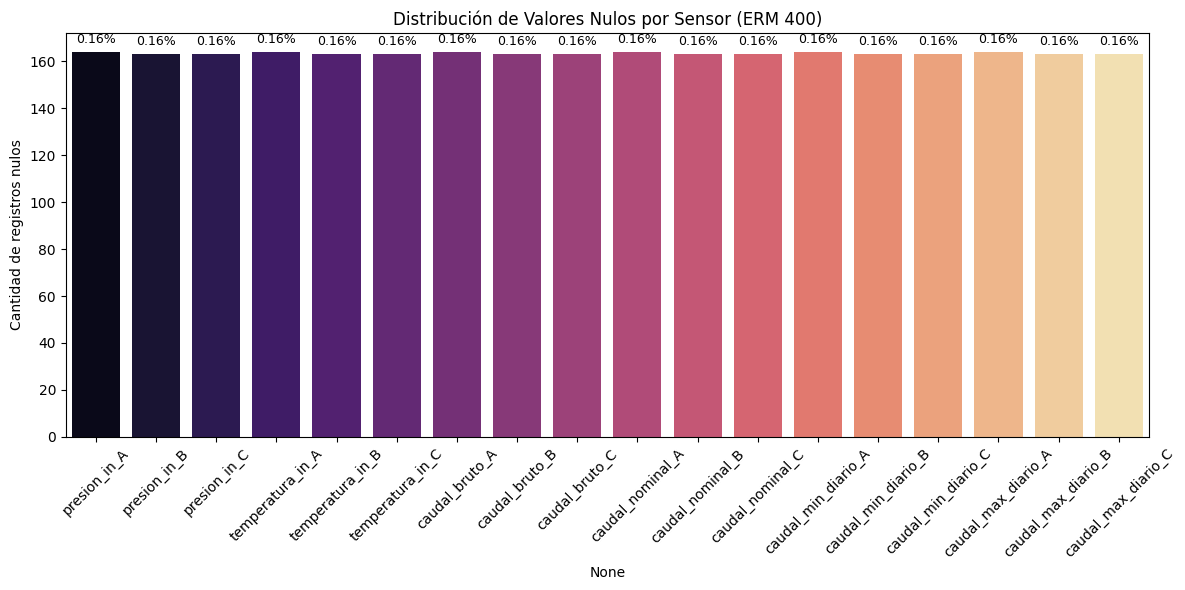

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos los nulos
nulos_por_columna = df.isnull().sum()
nulos_pct = (df.isnull().mean() * 100)

# 2. Creamos el gráfico
plt.figure(figsize=(12, 6))
# Usamos el índice de la serie para el eje X y los valores para el eje Y
ax = sns.barplot(x=nulos_por_columna.index, y=nulos_por_columna.values, palette='magma')

plt.xticks(rotation=45)
plt.title('Distribución de Valores Nulos por Sensor (ERM 400)')
plt.ylabel('Cantidad de registros nulos')

# 3. Añadir etiquetas de porcentaje sobre las barras (Corregido)
# Usamos .iloc[i] para acceder por posición numérica y evitar el KeyError
for i, p in enumerate(ax.patches):
    porcentaje = nulos_pct.iloc[i] # Acceso por posición
    ax.annotate(f'{porcentaje:.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

Tratamiento de Valores Faltantes(Nulos)

In [73]:
# Lógica: Si falla el sensor un momento, tomamos el último valor conocido
#  (estabilidad física)
df = df.ffill()

C:\Users\braya\AppData\Local\Temp\ipykernel_24396\3011619838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=nulos_final.index, y=nulos_final.values, palette='viridis')


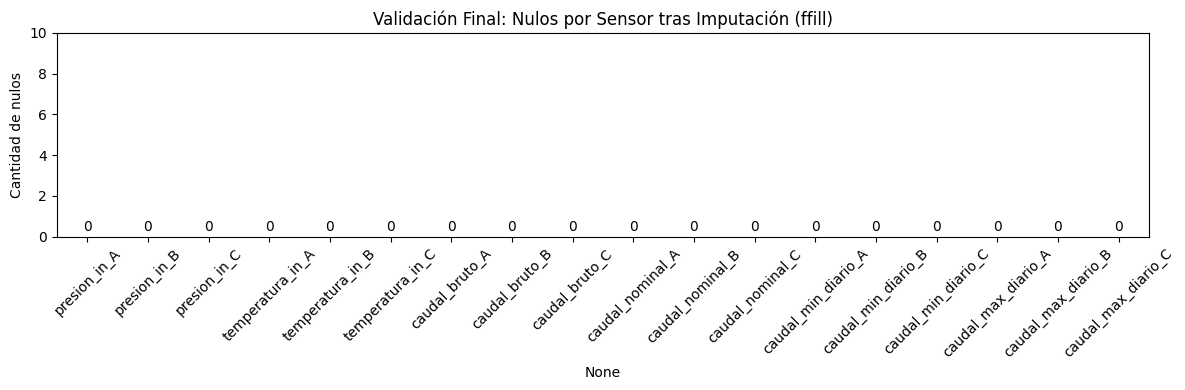

Total de nulos en el dataset: 0


In [74]:
# --- VALIDACIÓN POST-LIMPIEZA ---
nulos_final = df.isnull().sum()

plt.figure(figsize=(12, 4))
ax = sns.barplot(x=nulos_final.index, y=nulos_final.values, palette='viridis')
plt.title('Validación Final: Nulos por Sensor tras Imputación (ffill)')
plt.ylabel('Cantidad de nulos')
plt.xticks(rotation=45)

# Añadimos etiquetas (deberían ser todas "0")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 7), textcoords = 'offset points')

plt.ylim(0, max(nulos_final.values) + 10 if max(nulos_final.values) > 0 else 10)
plt.tight_layout()
plt.show()

print(f"Total de nulos en el dataset: {df.isnull().sum().sum()}")

In [75]:
df.head(2)

,presion_in_A,presion_in_B,presion_in_C,temperatura_in_A,temperatura_in_B,temperatura_in_C,caudal_bruto_A,caudal_bruto_B,caudal_bruto_C,caudal_nominal_A,caudal_nominal_B,caudal_nominal_C,caudal_min_diario_A,caudal_min_diario_B,caudal_min_diario_C,caudal_max_diario_A,caudal_max_diario_B,caudal_max_diario_C
datetime,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,17.124897,17.114777,17.114777,5.719018,7.483863,10.334971,1846.089820,1561.679383,0.0,31869.921725,26747.092334,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38
2022-01-01 00:05:00,17.127205,17.117367,17.118143,5.895065,7.342698,10.532716,1831.851803,1518.767362,0.0,31605.431151,26031.402012,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38


3. Verificación de Tipos: Asegurar que todo sea float64 (excepto el índice).

In [76]:
df.dtypes

presion_in_A           float64
presion_in_B           float64
presion_in_C           float64
temperatura_in_A       float64
temperatura_in_B       float64
temperatura_in_C       float64
caudal_bruto_A         float64
caudal_bruto_B         float64
caudal_bruto_C         float64
caudal_nominal_A       float64
caudal_nominal_B       float64
caudal_nominal_C       float64
caudal_min_diario_A    float64
caudal_min_diario_B    float64
caudal_min_diario_C    float64
caudal_max_diario_A    float64
caudal_max_diario_B    float64
caudal_max_diario_C    float64
dtype: object

4. Gráfico de "Líneas de Tiempo" al final para mostrar que no hay "huecos" después de la limpieza.

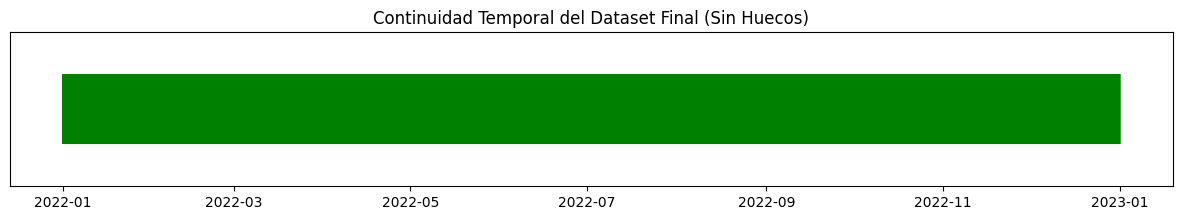

In [77]:
plt.figure(figsize=(15, 2))
plt.eventplot(df.index, orientation='horizontal', colors='green', linewidths=0.1)
plt.title('Continuidad Temporal del Dataset Final (Sin Huecos)')
plt.yticks([])
plt.show()

5. Preprocesamiento de dataset de Avisos SAP

In [78]:
# 1. Lista de columnas que parecen fechas en dataset de SAP
cols_fechas_sap = ['Inicio deseado', 'Fin deseado', 'Inicio avería', 'Fin de avería']

# 2. Convertir todas a datetime (los errores se convierten en NaT automáticamente)
for col in cols_fechas_sap:
    df_sap[col] = pd.to_datetime(df_sap[col], errors='coerce')

In [79]:
df_sap

,Aviso,DESCRIPCIÓN AVISO,UT,Denominación,Equipo,Denominación.1,GR-SUBGR,TAMAÑO ERM,Aviso externo,Orden,Inicio deseado,Fin deseado,Inicio avería,Ini.avería (h),Fin de avería,Fin de avería.1,Ce.emplazam.,COMENTARIOS AVISOS
7,10216955,Regulación. Disparo VIS LA/LB,ERM_6500,Regulación,5.000102e+09,02024 Válvula de seguridad interr VIS1A,2024.0,"G-6500 12""",20210823-026-TM,400001745027,2021-08-23,2021-08-28,NaT,00:00:00,NaT,00:00:00,7416,Notificación de VIS activas en líneas A y B.\n...
8,10246720,Alarma Vis B- ERM_6500,ERM_6500,Regulación,5.000102e+09,02024 Válvula de seguridad interr VIS1B,2024.0,"G-6500 12""",20230330-082-IN,400002021885,2023-03-30,2023-03-30,NaT,00:00:00,NaT,00:00:00,7416,Avisa CPC indicando que existe señal de dispar...
9,10240481,Regulación viernes,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1B,17001.0,"G-6500 12""",20221125-067-IN,400001964000,2022-11-25,2022-11-30,NaT,00:00:00,NaT,00:00:00,7416,ERM_6500\n20221125067\n22:05 22:50 23:40\n...
39,10233093,ERM_6500 Fallo funcional Aperflux LA,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1A,17001.0,"G-6500 12""",NaN,400001885191,2022-06-20,2022-07-20,NaT,00:00:00,NaT,00:00:00,7416,"Fallo funcional, se detecta rotura de membrana..."
40,10230072,ERM_6500 Fallo regulacion Aperflux Linea B,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1B,17001.0,"G-6500 12""",NaN,400001855792,2022-04-27,2023-04-27,NaT,00:00:00,NaT,00:00:00,7416,Fallo regulacion y estanqueidad.
41,10251555,29/6/23 Subir presion en ERM ERM_6500,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP1APIL1,17003.0,"G-6500 12""",NaN,400002061129,2023-06-30,2023-07-30,NaT,00:00:00,NaT,00:00:00,7416,Subir presion linea A.
42,10233095,ERM_6500 Fallo funcional piloto ppal LA,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP1APIL1,17003.0,"G-6500 12""",NaN,400001885199,2022-06-20,2023-06-20,NaT,00:00:00,NaT,00:00:00,7416,Se sustituye piloto por nuevo equipo.
43,10230073,ERM_6500 sust piloto reg.ppal,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP1BPIL1,17003.0,"G-6500 12""",NaN,400001855794,2022-04-27,2022-05-27,NaT,00:00:00,NaT,00:00:00,7416,Sustituir piloto por uno de mejor eficiencia e...
44,10258960,22/11/23 2da.Linea ERM_6500,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP1BPIL1,17003.0,"G-6500 12""",NaN,400002122304,2023-11-23,2024-11-23,NaT,00:00:00,NaT,00:00:00,7416,se procede a poner la segunda linea en san ch...
45,10233096,ERM_6500 Fallo funcional piloto Monitor LA,ERM_6500,Regulación,5.000102e+09,17003 Regulador piloto VCP2APIL1,17003.0,"G-6500 12""",NaN,400001885203,2022-06-20,2022-07-20,NaT,00:00:00,NaT,00:00:00,7416,Se realiza limpieza pìloto y sustitucion de ma...


Tratamiento de SAP Avisos, para tener la columna fecha de fallo

In [80]:
# Combinamos la fecha con la hora de avería
df_sap['datetime_fallo'] = pd.to_datetime(
    df_sap['Inicio deseado'].dt.strftime('%Y-%m-%d') + ' ' + 
    df_sap['Ini.avería (h)'].astype(str)
)
df_sap[['Inicio deseado', 'Ini.avería (h)', 'datetime_fallo']]

,Inicio deseado,Ini.avería (h),datetime_fallo
7,2021-08-23,00:00:00,2021-08-23 00:00:00
8,2023-03-30,00:00:00,2023-03-30 00:00:00
9,2022-11-25,00:00:00,2022-11-25 00:00:00
39,2022-06-20,00:00:00,2022-06-20 00:00:00
40,2022-04-27,00:00:00,2022-04-27 00:00:00
41,2023-06-30,00:00:00,2023-06-30 00:00:00
42,2022-06-20,00:00:00,2022-06-20 00:00:00
43,2022-04-27,00:00:00,2022-04-27 00:00:00
44,2023-11-23,00:00:00,2023-11-23 00:00:00
45,2022-06-20,00:00:00,2022-06-20 00:00:00


In [81]:
df.shape, df_sap.shape

((105109, 18), (19, 19))

6. Guardamos los datasets Preprocesados

In [82]:
# Definir la ruta de la carpeta 'processed'
base_path = r"C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas"
processed_path = os.path.join(base_path, "data", "processed")
os.makedirs(processed_path, exist_ok=True)

# 2. Guardar a CSV
# index=True es vital para que la columna 'datetime' se guarde en el archivo

#df.to_csv(os.path.join(processed_path, "df_sensores_ERM_400_2023_2024_limpio.csv"), index=True)
df.to_csv(os.path.join(processed_path, "df_sensores_ERM_6500_2022_2023_limpio.csv"), index=True)

#df_sap.to_csv(os.path.join(processed_path, "df_sap_erm_400_limpio.csv"), index=False)
df_sap.to_csv(os.path.join(processed_path, "df_sap_erm_6500_limpio.csv"), index=False)

print("Datos exportados correctamente en formato CSV para su uso futuro.")

Datos exportados correctamente en formato CSV para su uso futuro.
